# 1. Описание датасета "Used Cars Dataset"
Мы проводим исследование фиктивного датасета для разведочного анализа данных (EDA) и тестирования простых моделей прогнозирования. Датасет содержит 52 строк и 27 колонок.

Ссылка на датасет [Used Cars Dataset]: https://www.kaggle.com/datasets/shivanink8/used-cars-dataset

## 1.1. Цели:

1) Определение данных;
2) Формулирование гипотез;
3) Загрузка данных в Python;
4) Проверка данных;
5) Очистка данных;
6) Преобразование данных;
7) Выбор данных для анализа;
8) Агрегирование данных;
9) Визуализация данных;
10) Подтверждение или опровержение поставленных гипотез;
11) Формулирование ограничений и выводов.

## 1.2. Определение данных для анализа:

В качестве данных для анализа был выбран датасет «Used Cars Dataset». В датасете представлены набор данных примерно 52 подержанных автомобилей из autotrader.com и carfax.com

Для анализа будем чаще всего использовать следующие данные из датасета: ...

## 1.3. Описание данных

##### Содержимое в датасете
- `id`- индекс
- `brand` -  марка
- `model` - модель
- `year` - год выпуска 
- `miles` - пробег 
- `city mileage` - пробег по городу
- `highway mileage` - пробег по шоссе 
- `horsepower` - мощность
- `torque` - крутящий момент
- `engine capacity litre` - мощность двигателя
- `fuel capacity` - запас топлива
- `num cylinder` - количество цилиндров 
- `num set` - количество посадочных мест 
- `num owners` - количество владельцев
- `price` - цена
- `link` - ссылка
- `condition` - состояние
- `type` - тип
- `doors` - количество дверей
- `wheel drive` - привод на колесах
- `engine type` - тип двигателя
- `speed levels` - уровни оборота
- `front headroom` - запас хода спереди
- `front legroom` - передний запас для переднего привода
- `rear headroom` - запас хода сзади
- `rear legroom` - задний запас для заднего привода
- `service records` - сервисные записи

## 1.4. Выбор признаков для машинного обучения

Для машинного обучения выберем целевой признак - стоимость автомобиля. Сопоставим с остальными признаками, а именно, характеристики и конфигурации автомобиля выявяляем примерную стоимость автомобиля.- цена автомобиля


# 2. Предобработка и подготовка к машинному обучению

In [1]:
!pip install jupyternotify -q

In [2]:
# Уведомление о завершение работы определенного ячейка
import jupyternotify
%load_ext jupyternotify

C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\jupyternotify\jupyternotify.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


<IPython.core.display.Javascript object>

In [3]:
# Подключаем все необходимые библиотеки
import os
import re
import graphviz
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
from scipy.stats import (
    # Критерий Стьюдента
    ttest_ind, 
    f_oneway,
    # Тест Манна-Уитни, для гипотез H0 и H1
    mannwhitneyu,
    f_oneway,
    pearsonr
)

# Масштабируемость модели
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder, OneHotEncoder

# Время обучения модели
import timeit
from lightgbm import LGBMRegressor
# Вызов библиотеки для отключения предупреждения
import warnings

# Разбиение на обучающую, валидационную и тестовую выборку и кроссвалидацию для повышения качеств обучения
from sklearn.model_selection import train_test_split, GridSearchCV
# Конвейер
from sklearn.pipeline import make_pipeline

# и для машинного обучения разными способами (по условию мы выбираем линейную регрессию):
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_text, export_graphviz
from catboost import CatBoostRegressor
# Метод ближайшего соседа KNN
from sklearn.neighbors import KNeighborsRegressor
# Метод опорного вектора, SVR - для регрессии
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error

In [4]:
df = pd.read_csv('used_cars.csv')

## 2.1. Изучение данных

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     52 non-null     int64  
 1   brand                  52 non-null     object 
 2   model                  52 non-null     object 
 3   year                   52 non-null     int64  
 4   miles                  52 non-null     int64  
 5   city_mileage           52 non-null     int64  
 6   highway_mileage        52 non-null     int64  
 7   horsepower             52 non-null     int64  
 8   torque                 52 non-null     int64  
 9   engine_capacity_litre  52 non-null     float64
 10  fuel_capacity          52 non-null     float64
 11  num_cylinder           52 non-null     int64  
 12  num_seat               52 non-null     int64  
 13  num_owners             52 non-null     int64  
 14  price                  52 non-null     int64  
 15  link    

In [6]:
df.columns

Index(['id', 'brand', 'model', 'year', 'miles', 'city_mileage',
       'highway_mileage', 'horsepower', 'torque', 'engine_capacity_litre',
       'fuel_capacity', 'num_cylinder', 'num_seat', 'num_owners', 'price',
       'link', 'condition', 'type', 'doors', 'wheel_drive', 'engine_type',
       'speed_levels', 'front_headroom', 'front_legroom', 'rear_headroom',
       'rear_legroom', 'service_records'],
      dtype='object')

In [7]:
display(df.head())
display(df.tail())

,id,brand,model,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,...,type,doors,wheel_drive,engine_type,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
0,3,Chevrolet,Volt LT,2019,27173,43,42,149,294,1.5,...,sedan,4,2,hybrid_gas_electric,6.0,37.8,42.1,35.8,34.7,4
1,6,Hyundai,Elantra SE,2017,76941,29,38,146,132,2.0,...,sedan,4,2,gas,6.0,39.0,42.2,37.0,35.7,16
2,7,Ford,Focus,2014,97027,27,37,159,146,2.0,...,sedan,4,2,gas,6.0,38.3,43.7,38.0,33.2,13
3,8,Honda,Civic,2016,95396,31,42,158,138,1.5,...,sedan,4,2,gas,6.0,37.5,42.3,36.8,37.4,26
4,9,Hyundai,Elantra SE,2019,28405,29,38,147,132,2.0,...,sedan,4,2,gas,6.0,39.0,42.2,37.0,35.7,5


,id,brand,model,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,...,type,doors,wheel_drive,engine_type,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
47,53,Hyundai,Sonata,2019,33412,23,32,245,260,2.0,...,sedan,4,2,gas,8.0,40.4,45.5,38.0,35.6,10
48,54,Hyundai,Elantra SE,2020,13830,30,40,147,132,2.0,...,sedan,4,2,gas,6.0,40.3,42.2,37.3,35.7,6
49,55,Ford,Fusion,2019,23507,20,29,245,275,2.0,...,sedan,4,2,gas,6.0,39.2,44.3,37.8,38.3,11
50,56,Hyundai,Elantra SE,2020,11296,30,40,147,132,2.0,...,sedan,4,2,gas,6.0,40.3,42.2,37.3,35.7,7
51,57,Honda,Accord,2018,82729,30,38,192,192,1.5,...,sedan,4,2,gas,6.0,39.5,42.3,37.3,40.4,9


In [8]:
#Приведение к нижнему регистру и удаление лишних пробелов в названиях столбцов
df.columns = df.columns.str.strip().str.lower()

## 2.2. Преобразование данных

In [9]:
# Проверим объем занимаемой памяти в Мбайтах до преобразования
print(f'Объем датасета до преобразования: {df.memory_usage(deep=True).sum() / 1024 / 1024:.3f} Мбайт')  

Объем датасета до преобразования: 0.046 Мбайт


In [10]:
original_memory = df.memory_usage(deep=True).sum()

In [11]:
# Автоматизируем
def change_type_variable(dateframe, show_print_report=False):
    for name_column in dateframe:
        if(dateframe[name_column].dtype  == 'int64'):
            dateframe[name_column] = dateframe[name_column].astype('int32')
            if(show_print_report):
                print(f'Успешно, преобразовали в другой тип INT32 колонки: {name_column}')
        if(dateframe[name_column].dtype  == 'float64'):
            dateframe[name_column] = dateframe[name_column].astype('float32')
            if(show_print_report):
                print(f'Успешно, преобразовали в другой тип FLOAT32 колонки: {name_column}')
        if(name_column in ['accidents_or_damage', 'one_owner', 'personal_use_only']):
            dateframe[name_column] = dateframe[name_column].astype(bool)
    if not(show_print_report):
        print('Успешно, преобразованы в другой тип')

In [12]:
# Преобразуем их
change_type_variable(df)

Успешно, преобразованы в другой тип


In [13]:
# Проверим объем занимаемой памяти в Мбайтах до преобразования
print(f'Объем датасета после преобразования: {df.memory_usage(deep=True).sum() / 1024 / 1024:.3f} Мбайт')

Объем датасета после преобразования: 0.042 Мбайт


In [14]:
optimized_memory = df.memory_usage(deep=True).sum()

In [15]:
# Узнаем, сколько сэкономили памяти
savings_percentage = (original_memory - optimized_memory) / original_memory * 100
print(f"Сэкономлено {savings_percentage:.2f}% памяти")

Сэкономлено 9.50% памяти


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     52 non-null     int32  
 1   brand                  52 non-null     object 
 2   model                  52 non-null     object 
 3   year                   52 non-null     int32  
 4   miles                  52 non-null     int32  
 5   city_mileage           52 non-null     int32  
 6   highway_mileage        52 non-null     int32  
 7   horsepower             52 non-null     int32  
 8   torque                 52 non-null     int32  
 9   engine_capacity_litre  52 non-null     float32
 10  fuel_capacity          52 non-null     float32
 11  num_cylinder           52 non-null     int32  
 12  num_seat               52 non-null     int32  
 13  num_owners             52 non-null     int32  
 14  price                  52 non-null     int32  
 15  link    

## 2.3. Описательная статистика

In [17]:
df.describe()

,id,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,fuel_capacity,num_cylinder,...,price,condition,doors,wheel_drive,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,...,52.000000,1.0,52.0,52.000000,51.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,31.365385,2018.673077,33901.250000,29.038462,37.423077,176.865385,177.923077,1.832692,14.232693,4.038462,...,21763.423077,4.0,4.0,2.153846,6.313725,38.680771,42.467308,37.238468,37.632694,7.326923
std,15.378912,1.396370,22700.646139,5.947356,4.136619,33.793507,47.256433,0.379743,2.603973,0.277350,...,3532.455322,NaN,0.0,0.538138,0.761320,0.919087,1.045198,0.444202,1.604249,4.714272
min,3.000000,2014.000000,5000.000000,17.000000,24.000000,143.000000,99.000000,1.400000,7.000000,4.000000,...,13590.000000,4.0,4.0,2.000000,6.000000,37.500000,41.099998,35.799999,33.200001,1.000000
25%,18.750000,2018.000000,16454.750000,26.500000,35.750000,152.000000,138.000000,1.500000,12.400000,4.000000,...,19519.000000,4.0,4.0,2.000000,6.000000,37.724999,42.200001,37.074999,37.175001,4.000000
50%,31.500000,2019.000000,27448.500000,30.000000,38.000000,159.500000,181.000000,2.000000,13.600000,4.000000,...,21998.500000,4.0,4.0,2.000000,6.000000,38.500000,42.299999,37.200001,37.400002,6.000000
75%,44.250000,2019.250000,42442.000000,30.000000,40.000000,192.000000,192.000000,2.000000,15.050000,4.000000,...,22996.000000,4.0,4.0,2.000000,6.000000,39.299999,42.400002,37.500000,38.299999,10.000000
max,57.000000,2022.000000,97027.000000,55.000000,49.000000,288.000000,294.000000,3.500000,19.000000,6.000000,...,33777.000000,4.0,4.0,4.000000,9.000000,40.400002,45.500000,38.000000,40.400002,26.000000


## 2.4.Предобработка данных

### 2.4.1. Пропущенные значения

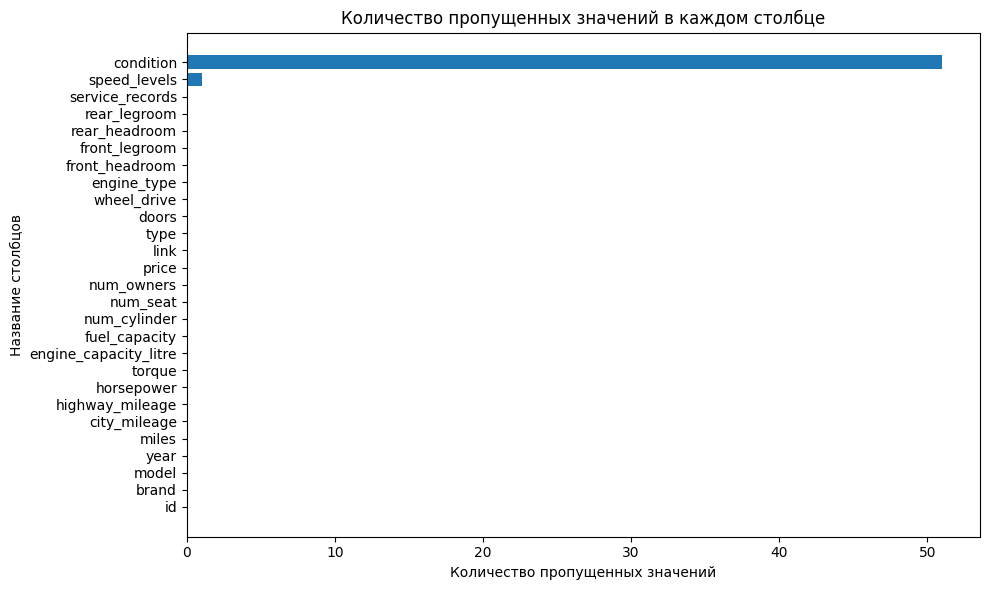

In [18]:
# Создаем список с именами столбцов и количеством пропущенных значений
missing_counts = [df[column].isnull().sum() for column in df.columns]

# Сортируем столбцы в порядке убывания количества пропущенных значений
sorted_columns, sorted_missing_counts = zip(*sorted(zip(df.columns, missing_counts), key=lambda x: x[1], reverse=False))

# Создаем горизонтальную столбчатую диаграмму
plt.figure(figsize=(10, 6))
# Используем barh для горизонтальных столбцов
plt.barh(sorted_columns, sorted_missing_counts)  
plt.xlabel('Количество пропущенных значений')
plt.ylabel('Название столбцов')
plt.title('Количество пропущенных значений в каждом столбце')
plt.tight_layout()

# Отображаем график
plt.show()

In [19]:
columns_isnull = [col for col, count in zip(sorted_columns, sorted_missing_counts) if count > 0]
print(f'Названий столбцов, у которых пропуски:')
for col in columns_isnull:
    print('\t' + col)

Названий столбцов, у которых пропуски:
	speed_levels
	condition


In [20]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in df.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = df[df[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

id - 0
brand - 0
model - 0
year - 0
miles - 0
city_mileage - 0
highway_mileage - 0
horsepower - 0
torque - 0
engine_capacity_litre - 0
fuel_capacity - 0
num_cylinder - 0
num_seat - 0
num_owners - 0
price - 0
link - 0
condition - 51
type - 0
doors - 0
wheel_drive - 0
engine_type - 0
speed_levels - 1
front_headroom - 0
front_legroom - 0
rear_headroom - 0
rear_legroom - 0
service_records - 0


In [21]:
# Замена пропусков медианой для 'speed_levels'
median_speed = df['speed_levels'].median()
df['speed_levels'].fillna(median_speed, inplace=True)

# Замена пропусков медианой для 'condition'
median_condition = df['condition'].median()
df['condition'].fillna(median_condition, inplace=True)

C:\Users\johns\AppData\Local\Temp\ipykernel_3100\1145979681.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['speed_levels'].fillna(median_speed, inplace=True)
C:\Users\johns\AppData\Local\Temp\ipykernel_3100\1145979681.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [22]:
# Проверим еще раз
for col in columns_isnull:
    print(f'Колонка: {col}; \t Кол-во пропусков: {df[col].isnull().sum()}')

Колонка: speed_levels; 	 Кол-во пропусков: 0
Колонка: condition; 	 Кол-во пропусков: 0


### 2.4.2. Дубликаты

In [23]:
# Количество дублирующих значений
df.duplicated().sum()

np.int64(0)

In [24]:
df.describe()

,id,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,fuel_capacity,num_cylinder,...,price,condition,doors,wheel_drive,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,...,52.000000,52.0,52.0,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,31.365385,2018.673077,33901.250000,29.038462,37.423077,176.865385,177.923077,1.832692,14.232693,4.038462,...,21763.423077,4.0,4.0,2.153846,6.307693,38.680771,42.467308,37.238468,37.632694,7.326923
std,15.378912,1.396370,22700.646139,5.947356,4.136619,33.793507,47.256433,0.379743,2.603973,0.277350,...,3532.455322,0.0,0.0,0.538138,0.755073,0.919087,1.045198,0.444202,1.604249,4.714272
min,3.000000,2014.000000,5000.000000,17.000000,24.000000,143.000000,99.000000,1.400000,7.000000,4.000000,...,13590.000000,4.0,4.0,2.000000,6.000000,37.500000,41.099998,35.799999,33.200001,1.000000
25%,18.750000,2018.000000,16454.750000,26.500000,35.750000,152.000000,138.000000,1.500000,12.400000,4.000000,...,19519.000000,4.0,4.0,2.000000,6.000000,37.724999,42.200001,37.074999,37.175001,4.000000
50%,31.500000,2019.000000,27448.500000,30.000000,38.000000,159.500000,181.000000,2.000000,13.600000,4.000000,...,21998.500000,4.0,4.0,2.000000,6.000000,38.500000,42.299999,37.200001,37.400002,6.000000
75%,44.250000,2019.250000,42442.000000,30.000000,40.000000,192.000000,192.000000,2.000000,15.050000,4.000000,...,22996.000000,4.0,4.0,2.000000,6.000000,39.299999,42.400002,37.500000,38.299999,10.000000
max,57.000000,2022.000000,97027.000000,55.000000,49.000000,288.000000,294.000000,3.500000,19.000000,6.000000,...,33777.000000,4.0,4.0,4.000000,9.000000,40.400002,45.500000,38.000000,40.400002,26.000000


## 2.5. Отсев до определенного кол-во уникальных значений

Для кодирования признаков OHE или OH будет черевато, если оставить много уникальных названия, потому что это приведет к созданию много новых признаков. Отсеиваем до небольших количеств, то есть сделаем так, чтобы создали максимум небольших новых закодированных признаков..

In [25]:
# Сделаем копию датасета
df_copy = df.copy()

In [26]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     52 non-null     int32  
 1   brand                  52 non-null     object 
 2   model                  52 non-null     object 
 3   year                   52 non-null     int32  
 4   miles                  52 non-null     int32  
 5   city_mileage           52 non-null     int32  
 6   highway_mileage        52 non-null     int32  
 7   horsepower             52 non-null     int32  
 8   torque                 52 non-null     int32  
 9   engine_capacity_litre  52 non-null     float32
 10  fuel_capacity          52 non-null     float32
 11  num_cylinder           52 non-null     int32  
 12  num_seat               52 non-null     int32  
 13  num_owners             52 non-null     int32  
 14  price                  52 non-null     int32  
 15  link    

In [27]:
# Функция, которая разделяет численные и категориальные признаки
def divide_features(df):
    numerical_features = df.select_dtypes(include=['number']).columns
    categorical_features = df.select_dtypes(exclude=['number']).columns
    
    return numerical_features, categorical_features

In [28]:
numerical_features, categorical_features = divide_features(df)

In [29]:
print("Численные признаки:", numerical_features.to_list())

Численные признаки: ['id', 'year', 'miles', 'city_mileage', 'highway_mileage', 'horsepower', 'torque', 'engine_capacity_litre', 'fuel_capacity', 'num_cylinder', 'num_seat', 'num_owners', 'price', 'condition', 'doors', 'wheel_drive', 'speed_levels', 'front_headroom', 'front_legroom', 'rear_headroom', 'rear_legroom', 'service_records']


In [30]:
print("Нечисленные признаки:", categorical_features.to_list())

Нечисленные признаки: ['brand', 'model', 'link', 'type', 'engine_type']


In [31]:
# Можно закодировать, ибо не так уж много разных уникальных признаков
df_copy['brand'].value_counts()

brand
Honda         23
Volkswagen    11
Hyundai        7
Ford           5
Chevrolet      3
Subaru         3
Name: count, dtype: int64

In [32]:
# Можно закодировать, ибо не так уж много разных уникальных признаков
df_copy['model'].value_counts()

model
Civic         14
Jetta          7
Accord         7
Passat         4
Elantra SE     4
Sonata         3
Fusion         3
Impreza        2
Malibu         2
Volt LT        1
Focus          1
Clarity        1
Legacy         1
Taurus         1
Insight        1
Name: count, dtype: int64

In [33]:
# Можно закодировать, ибо не так уж много разных уникальных признаков
df_copy['type'].value_counts()

type
sedan    52
Name: count, dtype: int64

In [34]:
# Можно закодировать, ибо не так уж много разных уникальных признаков
df_copy['engine_type'].value_counts()

engine_type
gas                    49
hybrid_gas_electric     3
Name: count, dtype: int64

# 3. Машинное обучение

In [35]:
# Здесь сохраняем результаты машинного обучения
results = pd.DataFrame()

# Счетчтик для нумерация моеделй
count_model = 0

## 3.1. Деление на обучающей и тестовой выборки

In [36]:
# Получаем признак и цель 
features = df.drop(['price', 'link'], axis=1)
target = df['price']

In [37]:
# Разделим на обучающую и тестовую выборку
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=12345)

## 3.2. Кодирование признаков - прямое кодирование (One-Hot Encoding)

Закодируем признаки: `brand`, `model`, `type`, `engine type`

_**Памятка себе:**_

**Модели основанные на деревьях (все модели в проекте кроме Линейной) могут работать с порядковым кодированием категорий (OrdinalEncoding).**

**OHE сильно раздувает размерность данных, что сказывается на вычислительной нагрузке (времени).**

In [38]:
# Выбираем категориальные признаки
# 'brand', 'model', 'type', 'engine_type'
categorical_features = ['brand', 'model', 'type', 'engine_type']

In [39]:
# Кодируем
encoder_ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
display(encoder_ohe)

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [40]:
# Обучаем энкодер на заданных категориальных признаках тренировочной выборки
encoder_ohe.fit(features_train[categorical_features])

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [41]:
# Добавляем закодированные признаки в X_train_ohe
# Encoder_ohe.get_feature_names_out() позволяет получить названия колонок
features_train[encoder_ohe.get_feature_names_out()] = encoder_ohe.transform(features_train[categorical_features])

In [42]:
# Энкодером, который обучен на тренировочной выборке, кодируем тестовую
features_test[encoder_ohe.get_feature_names_out()] = encoder_ohe.transform(features_test[categorical_features])

C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [43]:
# удаляем незакодированные категориальные признаки (изначальные колонки)
features_train = features_train.drop(categorical_features, axis=1)
features_test = features_test.drop(categorical_features, axis=1)

In [44]:
display(features_train.head())
display(features_test.head())

,id,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,fuel_capacity,num_cylinder,...,model_Focus,model_Fusion,model_Impreza,model_Insight,model_Jetta,model_Malibu,model_Passat,model_Taurus,model_Volt LT,engine_type_hybrid_gas_electric
8,14,2019,25044,30,40,147,184,1.4,13.2,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
21,27,2020,35743,20,29,245,275,2.0,18.0,4,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,25,2019,24250,30,40,147,184,1.4,13.2,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,7,2014,97027,27,37,159,146,2.0,12.4,4,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,26,2019,38097,17,24,288,254,3.5,19.0,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


,id,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,fuel_capacity,num_cylinder,...,model_Focus,model_Fusion,model_Impreza,model_Insight,model_Jetta,model_Malibu,model_Passat,model_Taurus,model_Volt LT,engine_type_hybrid_gas_electric
26,32,2020,12395,30,38,192,192,1.5,14.8,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39,45,2020,36506,21,31,245,275,2.0,16.5,4,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38,44,2018,51279,30,38,192,192,1.5,14.8,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,31,2020,27457,23,34,174,206,2.0,18.5,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,12,2022,6811,27,35,182,176,2.5,18.5,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
# Устраняем случайные и возможные пропуски для избежания ошибок
features_train = features_train.dropna()
target_train = target_train[features_train.index]

features_test = features_test.dropna()
target_test = target_test[features_test.index]

## 3.3. Обучение модели

### 3.3.5. LightGBMRegressor

In [46]:
# Матрица гиперпараметров для LGBMRegressor
parameters = {
    'lgbmregressor__n_estimators': [10, 25],
    'lgbmregressor__learning_rate': [0.1, 0.3],
    'lgbmregressor__max_depth': [5, 15],
    'lgbmregressor__num_leaves': [5, 10],
}

# Инициализируем модель с параметрами и создаем конвейер
pipeline_scale = make_pipeline(StandardScaler(), LGBMRegressor())
model = GridSearchCV(pipeline_scale, param_grid=parameters, cv=5, scoring='neg_mean_absolute_error')
display(model)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'lgbmregressor__learning_rate': [0.1, 0.3], 'lgbmregressor__max_depth': [5, 15], 'lgbmregressor__n_estimators': [10, 25], 'lgbmregressor__num_leaves': [5, 10]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [47]:
%%notify -m f"{pipeline_scale.named_steps[pipeline_scale.steps[-1][0]].__class__.__name__}"
%%time

# Обучим модель на обучающей выборке
model.fit(features_train, target_train)
time = model.refit_time_
params = model.best_params_

# Узнаем MAE обучающей выборки
result_MAE_t = -model.best_score_
print('MAE TRAIN:', result_MAE_t)
print('TIME TRAIN [s]:', round(time, 2))

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 32, number of used features: 0
[LightGBM] [Info] Start training from score 21441.906250
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the 

C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRe

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 32, number of used features: 0
[LightGBM] [Info] Start training from score 21441.906250
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the 

C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRe

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 32, number of used features: 0
[LightGBM] [Info] Start training from score 21441.906250
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the 

...

C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRe

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRe

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50
[LightGBM] [Info] Number of data points in the train set: 41, number of used features: 4
[LightGBM] [Info] Start training from score 21192.365854
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

<IPython.core.display.Javascript object>

**Проверка на тестовой выборки**

In [48]:
%%time
start_time = timeit.default_timer()
# Получим предсказания на тестовой выборки
predictions = model.predict(features_test)

elapsed = round(timeit.default_timer() - start_time, 3)

# Узнаем MAE
result_MAE_v = mean_absolute_error(target_test, predictions)
print('MAE TEST:', result_MAE_v)
print('Предсказание:', predictions.mean())

MAE TEST: 3981.6298987640275
Предсказание: 20997.089767440866
CPU times: total: 0 ns
Wall time: 14.4 ms


C:\Users\johns\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [49]:
# Зафиксируем результаты
results[count_model] = pd.Series({
    'NAME': pipeline_scale.named_steps[pipeline_scale.steps[-1][0]].__class__.__name__, 
    'MAE TRAIN': result_MAE_t, 
    'MAE TEST': result_MAE_v, 
    'PREDICTIONS': predictions.mean(), 
    'TIME TRAINING [s]': model.refit_time_, 
    'TIME PREDICTION [s]': elapsed, 
    'PARAMETRS': model.best_params_
})

results[count_model]
count_model+=1

### 3.3.6. CatBoostRegressor

In [50]:
# Матрица гиперпараметров для CatBoostRegressor
parameters = {
    'catboostregressor__iterations': [6, 10],
    'catboostregressor__learning_rate': [0.1, 0.5],
    'catboostregressor__depth': [5, 15],
}

# Инициализируем модель с параметрами и создаем конвейер
pipeline_scale = make_pipeline(StandardScaler(), CatBoostRegressor())
model = GridSearchCV(pipeline_scale, param_grid=parameters, cv=5, scoring='neg_mean_absolute_error')
display(model)

,estimator,Pipeline(step...ion='RMSE'))])
,param_grid,"{'catboostregressor__depth': [5, 15], 'catboostregressor__iterations': [6, 10], 'catboostregressor__learning_rate': [0.1, 0.5]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [51]:
%%notify -m f"{pipeline_scale.named_steps[pipeline_scale.steps[-1][0]].__class__.__name__}"
%%time

# Обучим модель на обучающей выборке
model.fit(features_train, target_train)
time = model.refit_time_
params = model.best_params_

# Узнаем MAE обучающей выборки
result_MAE_t = -model.best_score_
print('MAE TRAIN:', result_MAE_t)
print('TIME TRAIN [s]:', round(time, 2))

0:	learn: 2845.7484962	total: 147ms	remaining: 734ms
1:	learn: 2762.9703235	total: 148ms	remaining: 297ms
2:	learn: 2703.9623452	total: 150ms	remaining: 150ms
3:	learn: 2617.8040325	total: 152ms	remaining: 76ms
4:	learn: 2537.4794895	total: 155ms	remaining: 30.9ms
5:	learn: 2475.0461407	total: 156ms	remaining: 0us
0:	learn: 3093.5770103	total: 2.04ms	remaining: 10.2ms
1:	learn: 3004.9092551	total: 3.81ms	remaining: 7.63ms
2:	learn: 2944.0790185	total: 5.62ms	remaining: 5.62ms
3:	learn: 2837.2355757	total: 7.09ms	remaining: 3.54ms
4:	learn: 2757.5055849	total: 8.37ms	remaining: 1.67ms
5:	learn: 2663.2917453	total: 9.64ms	remaining: 0us
0:	learn: 3021.4174416	total: 1.25ms	remaining: 6.27ms
1:	learn: 2929.1326330	total: 2.7ms	remaining: 5.39ms
2:	learn: 2854.7033440	total: 4.23ms	remaining: 4.23ms
3:	learn: 2776.7707923	total: 5.6ms	remaining: 2.8ms
4:	learn: 2709.5407752	total: 6.95ms	remaining: 1.39ms
5:	learn: 2642.7903657	total: 8.37ms	remaining: 0us
0:	learn: 2894.4680029	total: 1.2

<IPython.core.display.Javascript object>

**Проверка на тестовой выборки**

In [52]:
%%time
start_time = timeit.default_timer()
# Получим предсказания на тестовой выборки
predictions = model.predict(features_test)

elapsed = round(timeit.default_timer() - start_time, 3)

# Узнаем MAE
result_MAE_v = mean_absolute_error(target_test, predictions)
print('MAE TEST:', result_MAE_v)
print('Предсказание:', predictions.mean())

MAE TEST: 3584.1332071736456
Предсказание: 21432.976140606996
CPU times: total: 15.6 ms
Wall time: 13.1 ms


In [53]:
# Зафиксируем результаты
results[count_model] = pd.Series({
    'NAME': pipeline_scale.named_steps[pipeline_scale.steps[-1][0]].__class__.__name__, 
    'MAE TRAIN': result_MAE_t, 
    'MAE TEST': result_MAE_v, 
    'PREDICTIONS': predictions.mean(), 
    'TIME TRAINING [s]': model.refit_time_, 
    'TIME PREDICTION [s]': elapsed, 
    'PARAMETRS': model.best_params_
})

results[count_model]
count_model+=1

### 3.3.7. BaggingRegressor

In [54]:
# Матрица гиперпараметров для BaggingRegressor
parameters = {
    'baggingregressor__n_estimators': [10, 50],
    'baggingregressor__random_state': [12345] 
}

# Инициализируем модель с параметрами и создаем конвейер
# Инициализируем BaggingRegressor отдельно
bagging_model = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=10), random_state=12345)
pipeline_scale = make_pipeline(StandardScaler(), bagging_model)
model = GridSearchCV(pipeline_scale, param_grid=parameters, cv=5, scoring='neg_mean_absolute_error')
display(model)

,estimator,Pipeline(step...tate=12345))])
,param_grid,"{'baggingregressor__n_estimators': [10, 50], 'baggingregressor__random_state': [12345]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [55]:
%%notify -m f"{pipeline_scale.named_steps[pipeline_scale.steps[-1][0]].__class__.__name__}"
%%time

# Обучим модель на обучающей выборке
model.fit(features_train, target_train)
time = model.refit_time_
params = model.best_params_

# Узнаем MAE обучающей выборки
result_MAE_t = -model.best_score_
print('MAE TRAIN:', result_MAE_t)
print('TIME TRAIN [s]:', round(time, 2))

MAE TRAIN: 2225.157638888889
TIME TRAIN [s]: 0.08
CPU times: total: 1.34 s
Wall time: 1.39 s


<IPython.core.display.Javascript object>

**Проверка на тестовой выборки**

In [56]:
%%time
start_time = timeit.default_timer()
# Получим предсказания на тестовой выборки
predictions = model.predict(features_test)

elapsed = round(timeit.default_timer() - start_time, 3)

# Узнаем MAE
result_MAE_v = mean_absolute_error(target_test, predictions)
print('MAE TEST:', result_MAE_v)
print('Предсказание:', predictions.mean())

MAE TEST: 3178.1702121212106
Предсказание: 22128.992272727275
CPU times: total: 31.2 ms
Wall time: 15.6 ms


In [57]:
# Зафиксируем результаты
results[count_model] = pd.Series({
    'NAME': pipeline_scale.named_steps[pipeline_scale.steps[-1][0]].__class__.__name__, 
    'MAE TRAIN': result_MAE_t, 
    'MAE TEST': result_MAE_v, 
    'PREDICTIONS': predictions.mean(), 
    'TIME TRAINING [s]': model.refit_time_, 
    'TIME PREDICTION [s]': elapsed, 
    'PARAMETRS': model.best_params_
})

results[count_model]
count_model+=1

### 3.3.8. StackingRegressor

In [58]:
# Матрица гиперпараметров для CatBoostRegressor
parameters = {
    'stackingregressor__final_estimator__C': [0.1, 1],  
    'stackingregressor__final_estimator__kernel': ['linear', 'rbf'],  
    'stackingregressor__cv': [3, 5], 
}
# Инициализируем базовые модели
base_models = [('dt', DecisionTreeRegressor()), ('knn', KNeighborsRegressor())]

# Инициализируем StackingRegressor с базовыми моделями
stacking_model = StackingRegressor(estimators=base_models, final_estimator=SVR())

# Создаем конвейер
pipeline_scale = make_pipeline(StandardScaler(), stacking_model)

model = GridSearchCV(pipeline_scale, param_grid=parameters, cv=5, scoring='neg_mean_absolute_error')
display(model)

,estimator,Pipeline(step...ator=SVR()))])
,param_grid,"{'stackingregressor__cv': [3, 5], 'stackingregressor__final_estimator__C': [0.1, 1], 'stackingregressor__final_estimator__kernel': ['linear', 'rbf']}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [59]:
%%notify -m f"{pipeline_scale.named_steps[pipeline_scale.steps[-1][0]].__class__.__name__}"
%%time

# Обучим модель на обучающей выборке
model.fit(features_train, target_train)
time = model.refit_time_
params = model.best_params_

# Узнаем MAE обучающей выборки
result_MAE_t = -model.best_score_
print('MAE TRAIN:', result_MAE_t)
print('TIME TRAIN [s]:', round(time, 2))

MAE TRAIN: 2443.9839189656363
TIME TRAIN [s]: 0.03
CPU times: total: 6.98 s
Wall time: 3.33 s


<IPython.core.display.Javascript object>

**Проверка на тестовой выборки**

In [60]:
%%time
start_time = timeit.default_timer()
# Получим предсказания на тестовой выборки
predictions = model.predict(features_test)

elapsed = round(timeit.default_timer() - start_time, 3)

# Узнаем MAE
result_MAE_v = mean_absolute_error(target_test, predictions)
print('MAE TEST:', result_MAE_v)
print('Предсказание:', predictions.mean())

MAE TEST: 3392.4031166914424
Предсказание: 21983.33939436706
CPU times: total: 62.5 ms
Wall time: 15.4 ms


In [61]:
# Зафиксируем результаты
results[count_model] = pd.Series({
    'NAME': pipeline_scale.named_steps[pipeline_scale.steps[-1][0]].__class__.__name__, 
    'MAE TRAIN': result_MAE_t, 
    'MAE TEST': result_MAE_v, 
    'PREDICTIONS': predictions.mean(), 
    'TIME TRAINING [s]': model.refit_time_, 
    'TIME PREDICTION [s]': elapsed, 
    'PARAMETRS': model.best_params_
})

results[count_model]
count_model+=1

### 3.3.9. RandomForestRegressor

In [62]:
parameters_rf = {
    'randomforestregressor__n_estimators': [50, 100],
    'randomforestregressor__max_depth': [5, 10, None]
}

pipeline_rf = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=12345))
model_rf = GridSearchCV(pipeline_rf, param_grid=parameters_rf, cv=5, scoring='neg_mean_absolute_error')

model_rf.fit(features_train, target_train)
result_MAE_t_rf = -model_rf.best_score_
print('MAE TRAIN:', result_MAE_t_rf)

# Предсказание
predictions_rf = model_rf.predict(features_test)
result_MAE_v_rf = mean_absolute_error(target_test, predictions_rf)
print('MAE TEST:', result_MAE_v_rf)

# Сохраняем результат
results[count_model] = pd.Series({
    'NAME': 'RandomForestRegressor',
    'MAE TRAIN': result_MAE_t_rf,
    'MAE TEST': result_MAE_v_rf,
    'PREDICTIONS': predictions_rf.mean(),
    'TIME TRAINING [s]': model_rf.refit_time_,
    'TIME PREDICTION [s]': elapsed,
    'PARAMETRS': model_rf.best_params_
})
count_model += 1

MAE TRAIN: 2173.841519221553
MAE TEST: 3220.8239360920998


# 3.3.10. AdaBoostRegressor

In [63]:
parameters_ada = {
    'adaboostregressor__n_estimators': [50, 100],
    'adaboostregressor__learning_rate': [0.5, 1.0]
}

pipeline_ada = make_pipeline(StandardScaler(), AdaBoostRegressor(random_state=12345))
model_ada = GridSearchCV(pipeline_ada, param_grid=parameters_ada, cv=5, scoring='neg_mean_absolute_error')

model_ada.fit(features_train, target_train)
result_MAE_t_ada = -model_ada.best_score_
print('MAE TRAIN:', result_MAE_t_ada)

predictions_ada = model_ada.predict(features_test)
result_MAE_v_ada = mean_absolute_error(target_test, predictions_ada)
print('MAE TEST:', result_MAE_v_ada)

results[count_model] = pd.Series({
    'NAME': 'AdaBoostRegressor',
    'MAE TRAIN': result_MAE_t_ada,
    'MAE TEST': result_MAE_v_ada,
    'PREDICTIONS': predictions_ada.mean(),
    'TIME TRAINING [s]': model_ada.refit_time_,
    'TIME PREDICTION [s]': elapsed,
    'PARAMETRS': model_ada.best_params_
})
count_model += 1

MAE TRAIN: 2005.5893072686333
MAE TEST: 3479.2162878787863


## 3.4. Итог

### 3.4.1. Анализ моделей

In [64]:
%%notify -m "Total result"
results = pd.DataFrame(results).T

<IPython.core.display.Javascript object>

In [65]:
results

,NAME,MAE TRAIN,MAE TEST,PREDICTIONS,TIME TRAINING [s],TIME PREDICTION [s],PARAMETRS
0,LGBMRegressor,2540.615341,3981.629899,20997.089767,0.019042,0.01,"{'lgbmregressor__learning_rate': 0.1, 'lgbmreg..."
1,CatBoostRegressor,2327.74294,3584.133207,21432.976141,0.104445,0.009,"{'catboostregressor__depth': 5, 'catboostregre..."
2,BaggingRegressor,2225.157639,3178.170212,22128.992273,0.083427,0.015,"{'baggingregressor__n_estimators': 50, 'baggin..."
3,StackingRegressor,2443.983919,3392.403117,21983.339394,0.031802,0.013,"{'stackingregressor__cv': 3, 'stackingregresso..."
4,RandomForestRegressor,2173.841519,3220.823936,22141.987544,0.142147,0.013,"{'randomforestregressor__max_depth': 5, 'rando..."
5,AdaBoostRegressor,2005.589307,3479.216288,21876.618495,0.12304,0.013,"{'adaboostregressor__learning_rate': 0.5, 'ada..."


In [66]:
# Рассчитываем рейтинг с учетом указанных приоритетов
results['RATING'] = (
    0.5 * (1 - (results['MAE TEST'] / results['MAE TEST'].max())) +
    0.3 * (1 - (results['TIME TRAINING [s]'] / results['TIME TRAINING [s]'].max())) +
    0.2 * (1 - (results['TIME PREDICTION [s]'] / results['TIME PREDICTION [s]'].max()))
)
# Сортируем DataFrame по убыванию рейтинга
results = results.sort_values(by='RATING', ascending=False)

In [67]:
results

,NAME,MAE TRAIN,MAE TEST,PREDICTIONS,TIME TRAINING [s],TIME PREDICTION [s],PARAMETRS,RATING
3,StackingRegressor,2443.983919,3392.403117,21983.339394,0.031802,0.013,"{'stackingregressor__cv': 3, 'stackingregresso...",0.333542
0,LGBMRegressor,2540.615341,3981.629899,20997.089767,0.019042,0.01,"{'lgbmregressor__learning_rate': 0.1, 'lgbmreg...",0.326478
2,BaggingRegressor,2225.157639,3178.170212,22128.992273,0.083427,0.015,"{'baggingregressor__n_estimators': 50, 'baggin...",0.224824
1,CatBoostRegressor,2327.74294,3584.133207,21432.976141,0.104445,0.009,"{'catboostregressor__depth': 5, 'catboostregre...",0.209485
5,AdaBoostRegressor,2005.589307,3479.216288,21876.618495,0.12304,0.013,"{'adaboostregressor__learning_rate': 0.5, 'ada...",0.130083
4,RandomForestRegressor,2173.841519,3220.823936,22141.987544,0.142147,0.013,"{'randomforestregressor__max_depth': 5, 'rando...",0.122206
